In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/house-prices-advanced-regression-techniques/test.csv


In [2]:
df=pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv')

# Importing Necessary Libraries

In [3]:
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

# **STEP 1** Exploratory Data Analysis

In [4]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## i) Exploring data

In [5]:
df.shape

(1460, 81)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [7]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


# **STEP 2** Data PreProcessing

## i) Identifying Missing Value

In [8]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

<Axes: >

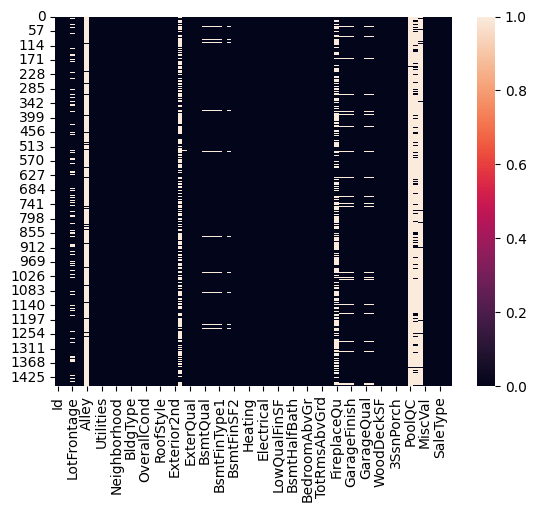

In [9]:
sns.heatmap(df.isnull())

## ii) Dropping Unecessary Column
### having more than 50% missing vals

In [10]:
df.drop(['Alley'],axis=1,inplace=True)
df.drop(['GarageYrBlt'],axis=1,inplace=True)
df.drop(['MasVnrType'],axis=1,inplace=True)
df.drop(['PoolQC','Fence','MiscFeature'],axis=1,inplace=True)

In [11]:
df.drop(['Id'],axis=1,inplace=True)

## iii) Handling Missing Values

In [12]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [13]:
for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

<Axes: >

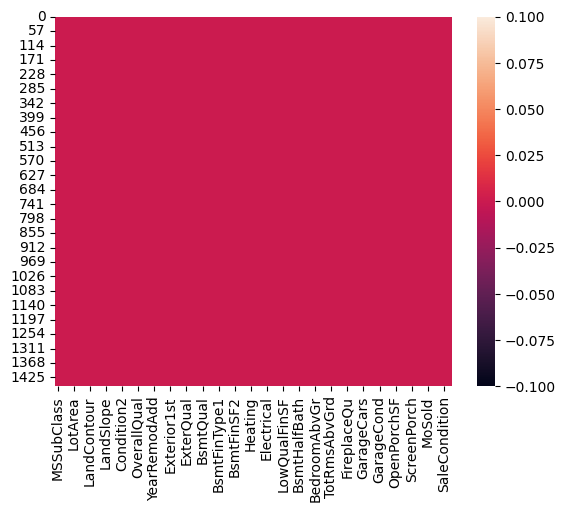

In [14]:
sns.heatmap(df.isnull())

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 74 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1460 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   LotShape       1460 non-null   object 
 6   LandContour    1460 non-null   object 
 7   Utilities      1460 non-null   object 
 8   LotConfig      1460 non-null   object 
 9   LandSlope      1460 non-null   object 
 10  Neighborhood   1460 non-null   object 
 11  Condition1     1460 non-null   object 
 12  Condition2     1460 non-null   object 
 13  BldgType       1460 non-null   object 
 14  HouseStyle     1460 non-null   object 
 15  OverallQual    1460 non-null   int64  
 16  OverallCond    1460 non-null   int64  
 17  YearBuilt      1460 non-null   int64  
 18  YearRemo

In [16]:
df.shape

(1460, 74)

## iv) Identifying Non-Numerical Column

In [17]:
print(cat_cols)

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
       'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
       'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='object')


## v) Segregating Ordinal Columns

In [18]:
ordinal_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 
                'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond']

for col in ordinal_cols:
    print(f"{col}: {df[col].dropna().unique().tolist()}")

ExterQual: ['Gd', 'TA', 'Ex', 'Fa']
ExterCond: ['TA', 'Gd', 'Fa', 'Po', 'Ex']
BsmtQual: ['Gd', 'TA', 'Ex', 'Fa']
BsmtCond: ['TA', 'Gd', 'Fa', 'Po']
HeatingQC: ['Ex', 'Gd', 'TA', 'Fa', 'Po']
KitchenQual: ['Gd', 'TA', 'Ex', 'Fa']
FireplaceQu: ['Gd', 'TA', 'Fa', 'Ex', 'Po']
GarageQual: ['TA', 'Fa', 'Gd', 'Ex', 'Po']
GarageCond: ['TA', 'Fa', 'Gd', 'Po', 'Ex']


## vi) Encoding Ordinal Column

In [19]:
ordinal_mapping = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, np.nan: 0}

for col in ordinal_cols:
    df[col] = df[col].map(ordinal_mapping)

## vii) Segregating Categorical Columns

In [20]:
nominal_cols = ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 
                'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 
                'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 
                'Foundation', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 
                'CentralAir', 'Electrical', 'Functional', 'GarageType', 'GarageFinish', 
                'PavedDrive', 'SaleType', 'SaleCondition']


## viii) Encoding Categorical Column (One Hot Encoding)

In [21]:
# Apply OneHotEncoding
encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False) # Avoid dummy variable trap
encoded_array = encoder.fit_transform(df[nominal_cols])

# Convert to DataFrame
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(nominal_cols))

# Drop original nominal columns and merge encoded ones
df = df.drop(columns=nominal_cols).reset_index(drop=True)
df = pd.concat([df, encoded_df], axis=1)

# STEP 3: Train Test Splitting

In [22]:
# Define features and target variable
X = df.drop('SalePrice', axis=1)  # Features
y = df['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **STEP 4:** Multiple Linear Regression Model

## i) Training the Multiple Linear Regression Model


In [23]:
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

## ii) Predict the Test Set Results

In [24]:
# Predict the target variable for test data
y_pred = regressor.predict(X_test)

# Display predicted values vs actual values
predictions_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(predictions_df.head())


      Actual      Predicted
892   154500  149315.967292
1105  325000  339710.223811
413   115000  104516.079120
522   159000  176534.095572
1036  315500  304873.309522


## iii) Evaluate the Model Performance

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)   # Mean Absolute Error
mse = mean_squared_error(y_test, y_pred)    # Mean Squared Error
rmse = mse ** 0.5  # Root Mean Squared Error
r2 = r2_score(y_test, y_pred)  # R-squared score

# Print results
print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R-squared Score (R²): {r2:.4f}')


Mean Absolute Error (MAE): 21351.83
Mean Squared Error (MSE): 2589367494.78
Root Mean Squared Error (RMSE): 50885.83
R-squared Score (R²): 0.6624


## iv) Visualize the Results
📈 Scatter Plot of Actual vs. Predicted Values

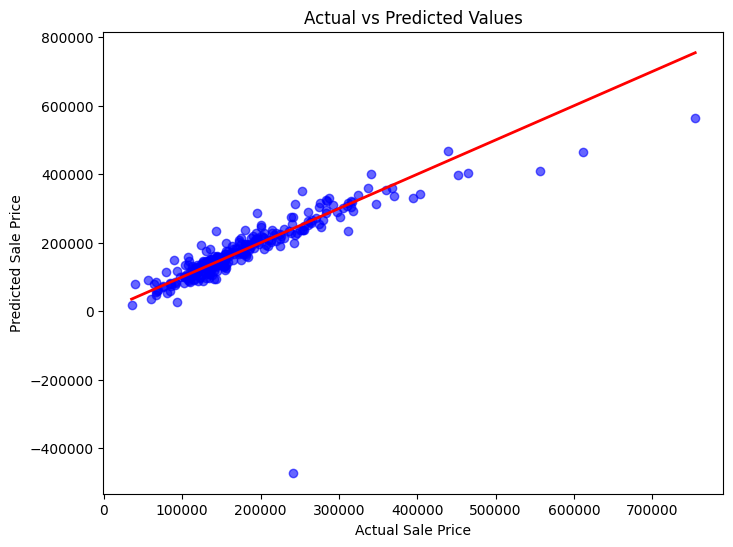

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)  # Perfect fit line
plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.title('Actual vs Predicted Values')
plt.show()


# **STEP 5:** MLR Model Using Backward Elimination

## i) Add a constant (intercept)

In [27]:
# Add a constant for the intercept
X_train_with_const = sm.add_constant(X_train)

## ii) Backward elimination

In [28]:
# Backward Elimination
def backward_elimination(X, y, significance_level=0.05):
    X_with_const = sm.add_constant(X)  # Add constant
    model = sm.OLS(y, X_with_const).fit()  # Fit the model
    while True:
        # Get p-values
        p_values = model.pvalues
        # Find the feature with the highest p-value
        max_p_value = p_values.max()
        if max_p_value > significance_level:
            # Remove the feature with the highest p-value
            feature_to_remove = p_values.idxmax()
            X = X.drop(columns=[feature_to_remove])
            model = sm.OLS(y, sm.add_constant(X)).fit()  # Refit the model
        else:
            break
    return X, model

# Perform backward elimination
X_final, final_model = backward_elimination(X_train, y_train)

# Display the summary of the final model
print(final_model.summary())


                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.907
Method:                 Least Squares   F-statistic:                     178.6
Date:                Sun, 09 Mar 2025   Prob (F-statistic):               0.00
Time:                        15:37:57   Log-Likelihood:                -13383.
No. Observations:                1168   AIC:                         2.690e+04
Df Residuals:                    1103   BIC:                         2.723e+04
Df Model:                          64                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                 -1.297e+

## iii)  Predict Test Set Results

In [29]:
# Make predictions on the test set
X_test_final = X_test[X_final.columns] 
X_test_final_with_const = sm.add_constant(X_test_final)
y_pred = final_model.predict(X_test_final_with_const)

## iv) Evaluate Model Performance

In [30]:

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred) 
mse = mean_squared_error(y_test, y_pred)    
rmse = mse ** 0.5  # Root Mean Squared Error
r2 = r2_score(y_test, y_pred)  # R-squared score

# Print results
print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R-squared Score (R²): {r2:.4f}')


Mean Absolute Error (MAE): 21705.28
Mean Squared Error (MSE): 2427208345.15
Root Mean Squared Error (RMSE): 49266.71
R-squared Score (R²): 0.6836


## v) Visualise the Result 

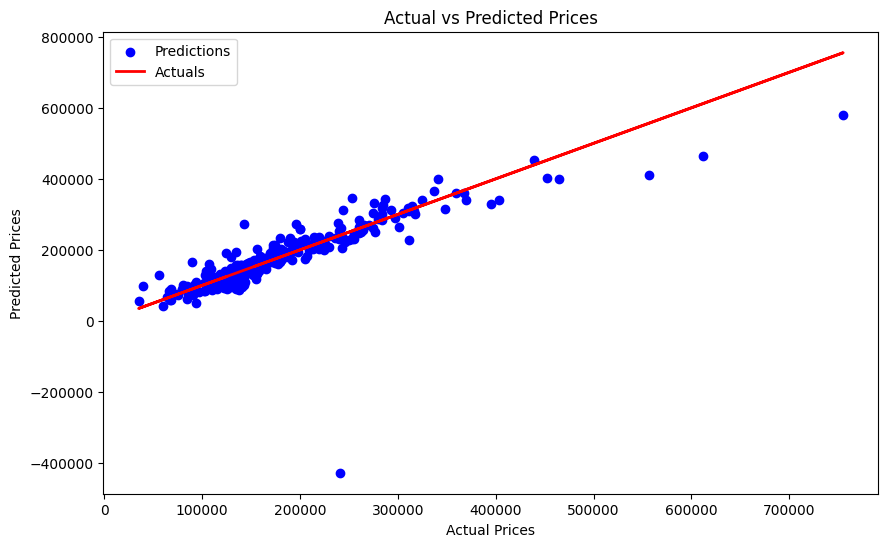

In [31]:
# Visualize the results
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predictions')
plt.plot(y_test, y_test, color='red', linewidth=2, label='Actuals')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.legend()
plt.show()

# **STEP 6:** MLR Model Using Forward Elimination

## i) MLR using Forward Selection

In [32]:
def forward_selection(X, y, significance_level=0.05):
    selected_features = []
    remaining_features = list(X.columns)
    
    while remaining_features:
        best_feature = None
        best_p_value = float('inf')
        
        for feature in remaining_features:
            model = sm.OLS(y, sm.add_constant(X[selected_features + [feature]])).fit()
            p_value = model.pvalues[feature]
            
            if p_value < best_p_value:
                best_p_value = p_value
                best_feature = feature
        
        if best_p_value < significance_level:
            selected_features.append(best_feature)
            remaining_features.remove(best_feature)
        else:
            break
    
    return X[selected_features], selected_features
# Perform forward selection
X_final, selected_features = forward_selection(X_train, y_train)

# Fit the final model with selected features
final_model = sm.OLS(y_train, sm.add_constant(X_final)).fit()

# Display the summary of the final model
print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.910
Model:                            OLS   Adj. R-squared:                  0.906
Method:                 Least Squares   F-statistic:                     201.5
Date:                Sun, 09 Mar 2025   Prob (F-statistic):               0.00
Time:                        15:39:17   Log-Likelihood:                -13394.
No. Observations:                1168   AIC:                         2.690e+04
Df Residuals:                    1111   BIC:                         2.719e+04
Df Model:                          56                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                -1.267e+06 

## ii) Predict the Test Set

In [33]:
# Make predictions on the test set
X_test_final = X_test[selected_features]  # Ensure the test set has the same features
X_test_final_with_const = sm.add_constant(X_test_final)
y_pred = final_model.predict(X_test_final_with_const)


## iii)Evaluate Model Performance

In [34]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)   # Mean Absolute Error
mse = mean_squared_error(y_test, y_pred)    # Mean Squared Error
rmse = mse ** 0.5  # Root Mean Squared Error
r2 = r2_score(y_test, y_pred)  # R-squared score

# Print results
print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R-squared Score (R²): {r2:.4f}')


Mean Absolute Error (MAE): 20545.46
Mean Squared Error (MSE): 2226228081.29
Root Mean Squared Error (RMSE): 47182.92
R-squared Score (R²): 0.7098


## iv) Visualize the results

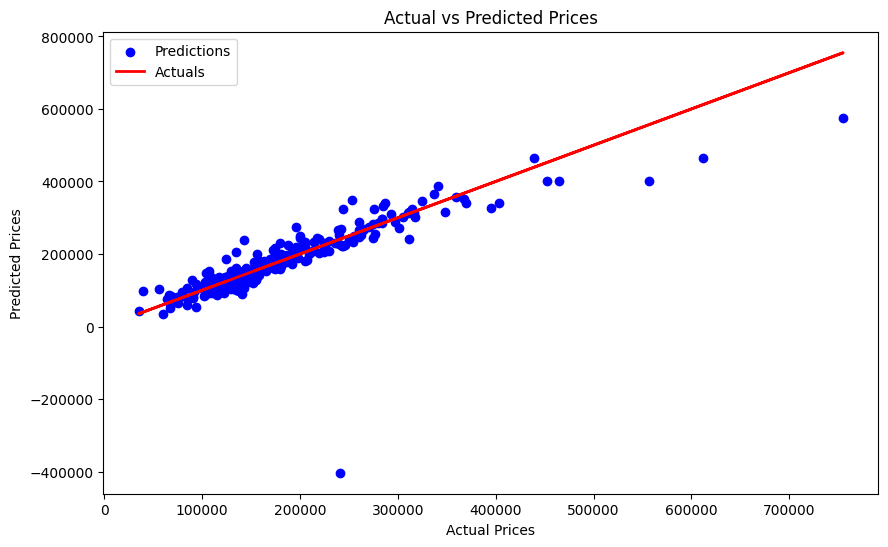

In [35]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predictions')
plt.plot(y_test, y_test, color='red', linewidth=2, label='Actuals')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.legend()
plt.show()

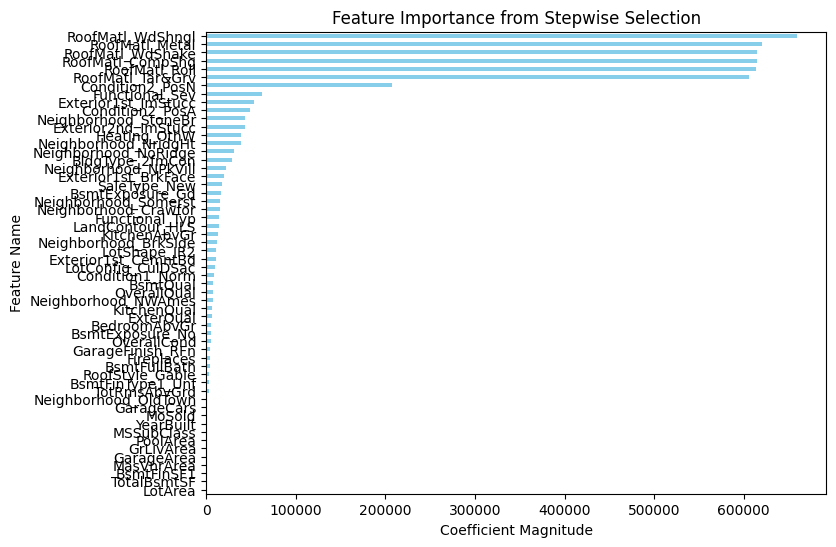

In [36]:
feature_importance = abs(final_model.params[1:])  # Ignore intercept
feature_importance.sort_values(ascending=True).plot(kind='barh', figsize=(8, 6), color='skyblue')
plt.xlabel("Coefficient Magnitude")
plt.ylabel("Feature Name")
plt.title("Feature Importance from Stepwise Selection")
plt.show()

# **STEP 7:** MLR Model Using Step wise Selection

## i) Step-wise Selection

In [37]:
# Stepwise Selection
def stepwise_selection(X, y, significance_level=0.05):
    selected_features = []
    remaining_features = list(X.columns)
    
    while True:
        # Forward selection
        best_feature = None
        best_p_value = float('inf')
        
        for feature in remaining_features:
            model = sm.OLS(y, sm.add_constant(X[selected_features + [feature]])).fit()
            p_value = model.pvalues[feature]
            
            if p_value < best_p_value:
                best_p_value = p_value
                best_feature = feature
        
        if best_p_value < significance_level:
            selected_features.append(best_feature)
            remaining_features.remove(best_feature)
        else:
            break
        
        # Backward elimination
        while selected_features:
            model = sm.OLS(y, sm.add_constant(X[selected_features])).fit()
            p_values = model.pvalues[1:]  # Exclude the constant
            max_p_value = p_values.max()
            
            if max_p_value >= significance_level:
                feature_to_remove = p_values.idxmax()
                selected_features.remove(feature_to_remove)
            else:
                break
    
    return X[selected_features], selected_features

# Perform stepwise selection
X_final, selected_features = stepwise_selection(X_train, y_train)

# Fit the final model with selected features
final_model = sm.OLS(y_train, sm.add_constant(X_final)).fit()

# Display the summary of the final model
print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.909
Model:                            OLS   Adj. R-squared:                  0.905
Method:                 Least Squares   F-statistic:                     223.8
Date:                Sun, 09 Mar 2025   Prob (F-statistic):               0.00
Time:                        15:40:34   Log-Likelihood:                -13401.
No. Observations:                1168   AIC:                         2.690e+04
Df Residuals:                    1117   BIC:                         2.716e+04
Df Model:                          50                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 -1.24e+06 

## ii) Predict the test set

In [38]:
# Make predictions on the test set
X_test_final = X_test[selected_features]  # Ensure the test set has the same features
X_test_final_with_const = sm.add_constant(X_test_final)
y_pred = final_model.predict(X_test_final_with_const)

## iii) Evaluate model performance 

In [39]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)   # Mean Absolute Error
mse = mean_squared_error(y_test, y_pred)    # Mean Squared Error
rmse = mse ** 0.5  # Root Mean Squared Error
r2 = r2_score(y_test, y_pred)  # R-squared score

# Print results
print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R-squared Score (R²): {r2:.4f}')

Mean Absolute Error (MAE): 20506.28
Mean Squared Error (MSE): 2175942463.23
Root Mean Squared Error (RMSE): 46647.00
R-squared Score (R²): 0.7163


## v) Visualize the results

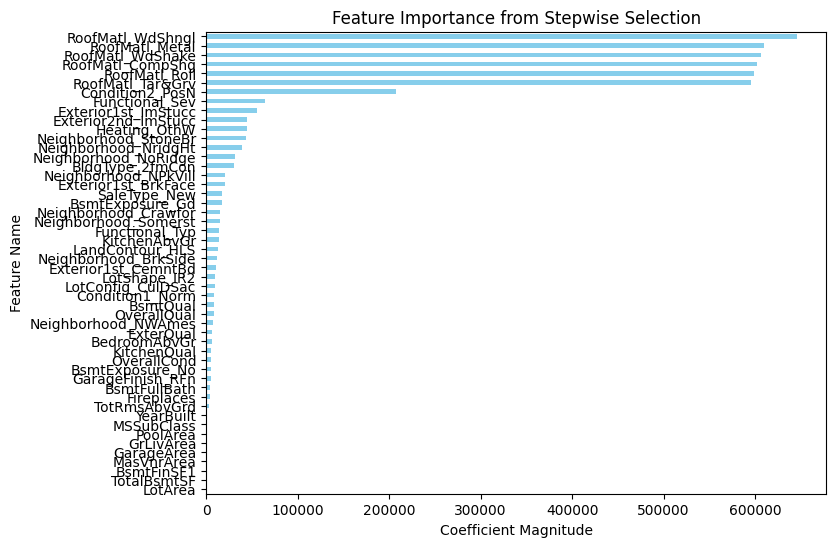

In [40]:
# # **Visualizing Feature Importance**
feature_importance = abs(final_model.params[1:])  # Ignore intercept
feature_importance.sort_values(ascending=True).plot(kind='barh', figsize=(8, 6), color='skyblue')
plt.xlabel("Coefficient Magnitude")
plt.ylabel("Feature Name")
plt.title("Feature Importance from Stepwise Selection")
plt.show()